In [ ]:
# --- System Dependencies ---
# Install Git LFS to correctly download large .tar files
!sudo apt-get update
!sudo apt-get install -y git-lfs
!git lfs install

# --- Python Libraries ---
# Install libraries missing from standard Colab/local environments
!pip install -q rasterio albumentations transformers torch torchvision evaluate

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
import os
import glob
import random
import subprocess
import sys
import shutil
import numpy as np
import rasterio
import torch
import albumentations as A
from torch import nn
from torch.utils.data import Dataset
from torchvision.transforms import functional as F
from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation,
    TrainingArguments,
    Trainer
)

# --- Experiment Configuration ---
class Config:
    # Experiment Identifiers
    EXPERIMENT_NAME = "segformer_b0_cems_fire"
    DATA_ROOT = "./extracted_data"

    # Data Parameters
    INPUT_BANDS = [11, 7, 3] # Sentinel-2 Indices (0-based): B12, B8, B4
    CROP_SIZE = (512, 512)

    # Model Architecture
    MODEL_CHECKPOINT = "nvidia/mit-b0"
    NUM_LABELS = 2
    ID2LABEL = {0: "Safe", 1: "Fire"}
    LABEL2ID = {"Safe": 0, "Fire": 1}

    # Training Hyperparameters
    BATCH_SIZE = 4
    LEARNING_RATE = 6e-5
    EPOCHS = 10
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # Set Reproducibility
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

print(f"⚙️ Configuration loaded for: {Config.EXPERIMENT_NAME}")
print(f"🔧 Device: {Config.DEVICE}")

⚙️ Configuration loaded for: segformer_b0_cems_fire
🔧 Device: cuda


In [ ]:
import os
import shutil
import subprocess
from pathlib import Path

class DataManager:
    """
    Standardized Data Manager for CEMS Wildfire Dataset.
    Handles Git LFS fetching and archive extraction.
    """
    REPO_URL = "https://huggingface.co/datasets/links-ads/wildfires-cems"
    REPO_DIR = Path("wildfires-cems")
    DATA_DIR = Path("extracted_data")

    @classmethod
    def setup_dataset(cls):
        print("🔄 Checking data setup...")

        # 1. Clone/Pull Repository
        if not cls.REPO_DIR.exists():
            print(f"⬇️ Cloning {cls.REPO_URL}...")
            subprocess.run(["git", "clone", cls.REPO_URL], check=True)

        # 2. Ensure Git LFS is pulled
        print("⬇️ Pulling LFS files (this may take time)...")
        subprocess.run(["git", "lfs", "install"], cwd=cls.REPO_DIR, check=True, stdout=subprocess.DEVNULL)
        subprocess.run(["git", "lfs", "pull"], cwd=cls.REPO_DIR, check=True)

        # 3. Extract Data
        if not cls.DATA_DIR.exists():
            cls.DATA_DIR.mkdir(parents=True, exist_ok=True)
            print("📦 Extracting archives...")

            # Combine split tar files and extract
            # Equivalent to: cat ... | tar -xzf -
            for split in ["train", "val"]:
                archive_path = cls.REPO_DIR / "data" / split
                print(f"   - Processing {split} set...")

                # Construct command to cat all parts and untar
                # Note: Python's tarfile library struggles with multi-part tars,
                # so using system tar is safer/faster here.
                cmd = f"cat {archive_path}/{split}.tar.* | tar -xzf - -i -C {cls.DATA_DIR}"
                subprocess.run(cmd, shell=True, check=True)

            print(f"✅ Extraction complete. Data ready in {cls.DATA_DIR}")
        else:
            print(f"✅ Data directory found at {cls.DATA_DIR}. Skipping extraction.")

# Usage in your notebook:
DataManager.setup_dataset()

🔄 Checking data setup...
⬇️ Cloning https://huggingface.co/datasets/links-ads/wildfires-cems...
⬇️ Pulling LFS files (this may take time)...
📦 Extracting archives...
   - Processing train set...
   - Processing val set...
✅ Extraction complete. Data ready in extracted_data


In [ ]:
class FireSegmentationDataset(Dataset):
    """
    Custom Dataset for Sentinel-2 Wildfire Segmentation.
    """
    def __init__(self, root_dir, processor, config, split="train"):
        self.root_dir = os.path.join(root_dir, split)
        self.processor = processor
        self.config = config
        self.bands = config.INPUT_BANDS

        self.image_paths = glob.glob(os.path.join(self.root_dir, "**", "*_S2L2A*.tif"), recursive=True)
        print(f"📂 [{split.upper()}] Loaded {len(self.image_paths)} samples.")

        # Data Augmentation Pipeline
        self.aug = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.RandomBrightnessContrast(p=0.2, brightness_limit=0.1, contrast_limit=0.1),
        ])

    def _normalize(self, image):
        # Normalize Sentinel-2 16-bit integers to [0, 1] float
        if image.max() > 255: return np.clip(image / 10000.0, 0, 1.0)
        elif image.max() > 1: return np.clip(image / 255.0, 0, 1.0)
        return np.clip(image, 0, 1.0)

    def _smart_crop(self, img_t, msk_t):
        # Centers crop on positive class (Fire) if present
        _, h, w = img_t.shape
        crop_h, crop_w = self.config.CROP_SIZE

        if h <= crop_h or w <= crop_w: return img_t, msk_t

        fire_indices = torch.nonzero(msk_t.squeeze())

        # 80% chance to focus on fire if it exists
        if len(fire_indices) > 0 and random.random() < 0.8:
            idx = random.randint(0, len(fire_indices) - 1)
            center_y, center_x = fire_indices[idx]
            top = max(0, min(int(center_y) - crop_h // 2, h - crop_h))
            left = max(0, min(int(center_x) - crop_w // 2, w - crop_w))
        else:
            top = random.randint(0, h - crop_h)
            left = random.randint(0, w - crop_w)

        return F.crop(img_t, top, left, crop_h, crop_w), F.crop(msk_t, top, left, crop_h, crop_w)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            img_path = self.image_paths[idx]

            # Locate corresponding mask
            mask_path = img_path.replace("_S2L2A", "_DEL")
            if not os.path.exists(mask_path): mask_path = img_path.replace("_S2L2A", "_GRA")

            # Load Image
            with rasterio.open(img_path) as src:
                image = src.read([b + 1 for b in self.bands]).astype(np.float32)
                image = self._normalize(image)

            # Load Mask
            with rasterio.open(mask_path) as src:
                mask = src.read(1).astype(np.float32)
                mask[mask > 0] = 1.0

            # Transform & Crop
            img_t, msk_t = self._smart_crop(torch.tensor(image), torch.tensor(mask).unsqueeze(0))

            # Augment
            img_np = img_t.permute(1, 2, 0).numpy()
            msk_np = msk_t.squeeze().numpy()
            if self.aug:
                augmented = self.aug(image=img_np, mask=msk_np)
                img_np, msk_np = augmented['image'], augmented['mask']

            # Process for Model
            encoded = self.processor(img_np, msk_np, return_tensors="pt", do_resize=False, do_rescale=False)

            return {
                "pixel_values": encoded.pixel_values.squeeze(),
                "labels": encoded.labels.squeeze().long()
            }
        except Exception:
            return self.__getitem__((idx + 1) % len(self))

In [ ]:
class HybridLoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)

        # Dice Loss calculation
        probs = torch.softmax(inputs, dim=1)
        fire_probs = probs[:, 1].contiguous().view(-1) # Class 1 = Fire
        targets_flat = targets.contiguous().view(-1)
        intersection = (fire_probs * targets_flat).sum()
        dice_score = (2. * intersection + self.smooth) / (fire_probs.sum() + targets_flat.sum() + self.smooth)

        return 0.5 * ce_loss + 0.5 * (1 - dice_score)

class SegmentationTrainer(Trainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = HybridLoss().to(Config.DEVICE)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Upsample logits to match ground truth resolution (SegFormer outputs 1/4 res)
        upsampled_logits = nn.functional.interpolate(
            logits, size=labels.shape[-2:], mode="bilinear", align_corners=False
        )

        loss = self.loss_fn(upsampled_logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
import logging
import numpy as np
import torch
import os
import evaluate
from torch import nn
from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import jaccard_score



# 1. SETUP & LOGGING
logging.getLogger("rasterio").setLevel(logging.ERROR)
os.environ["CPL_LOG"] = "/dev/null"

# 2. INITIALIZE PROCESSOR & MODEL
print(f"🚀 Loading Model: {Config.MODEL_CHECKPOINT}")
processor = SegformerImageProcessor.from_pretrained(
    Config.MODEL_CHECKPOINT,
    do_reduce_labels=False,
    do_resize=False,
    do_rescale=False
)

model = SegformerForSemanticSegmentation.from_pretrained(
    Config.MODEL_CHECKPOINT,
    num_labels=Config.NUM_LABELS,
    id2label=Config.ID2LABEL,
    label2id=Config.LABEL2ID,
    ignore_mismatched_sizes=True
)

# 3. PREPARE DATASETS
# (Re-initializing here ensures they use the correctly loaded processor)
train_ds = FireSegmentationDataset(Config.DATA_ROOT, processor, Config, split="train")
val_ds = FireSegmentationDataset(Config.DATA_ROOT, processor, Config, split="val")



# Load metric once
metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    """
    Standardized metrics for all Wildfire experiments.
    Reports: Mean IoU, Per-Class Accuracy, and 'Fire' class IoU.
    """
    logits, labels = eval_pred

    # Convert logits to predictions
    # Note: Segformer output is usually (Batch, Channels, H, W)
    logits_tensor = torch.from_numpy(logits)

    # Resize logits to match labels if necessary (Segformer outputs 1/4 res usually)
    if logits_tensor.shape[-2:] != labels.shape[-2:]:
        logits_tensor = torch.nn.functional.interpolate(
            logits_tensor,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    predictions = logits_tensor.argmax(dim=1).numpy()

    # Calculate metrics
    metrics = metric.compute(
        predictions=predictions,
        references=labels,
        num_labels=2,
        ignore_index=255, # Standard ignore index for boundaries/padding
        reduce_labels=False,
    )

    # Extract the specific "Fire" IoU (assuming class 1 is Fire)
    fire_iou = metrics["per_category_iou"][1] if len(metrics["per_category_iou"]) > 1 else 0.0

    return {
        "mean_iou": metrics["mean_iou"],
        "mean_accuracy": metrics["mean_accuracy"],
        "fire_iou": fire_iou,
    }

# 5. TRAINING ARGUMENTS
args = TrainingArguments(
    output_dir=f"./results/{Config.EXPERIMENT_NAME}",
    learning_rate=Config.LEARNING_RATE,
    num_train_epochs=Config.EPOCHS,
    per_device_train_batch_size=Config.BATCH_SIZE,
    per_device_eval_batch_size=Config.BATCH_SIZE,
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_steps=50,
    fp16=(Config.DEVICE == "cuda"),
    remove_unused_columns=False,
    report_to="none"
)

# 6. TRAIN
trainer = SegmentationTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print(f"🔥 Starting training on {Config.DEVICE}...")
trainer.train()

# 7. SAVE
save_path = f"./models/{Config.EXPERIMENT_NAME}"
trainer.save_model(save_path)
processor.save_pretrained(save_path)
print(f"🏆 Training finished. Model saved to {save_path}")

🚀 Loading Model: nvidia/mit-b0


/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.

📂 [TRAIN] Loaded 281 samples.
📂 [VAL] Loaded 53 samples.
🔥 Starting training on cuda...


Epoch,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Fire Iou
1,0.492300,0.474895,0.600418,0.725876,0.438658
2,0.417800,0.395054,0.646227,0.742176,0.478478
3,0.405800,0.376367,0.688497,0.780755,0.544499
4,0.388900,0.379593,0.668177,0.766879,0.513535
5,0.399600,0.428257,0.560295,0.799929,0.476326
6,0.346100,0.350072,0.668592,0.819983,0.561658
7,0.338300,0.395001,0.610104,0.829843,0.508860
8,0.321400,0.304819,0.758994,0.883334,0.662207
9,0.345700,0.317601,0.703682,0.840015,0.596812
10,0.341300,0.298457,0.749593,0.881623,0.674576


/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible 

🏆 Training finished. Model saved to ./models/segformer_b0_cems_fire


🧐 Inspecting Test Sample #34...


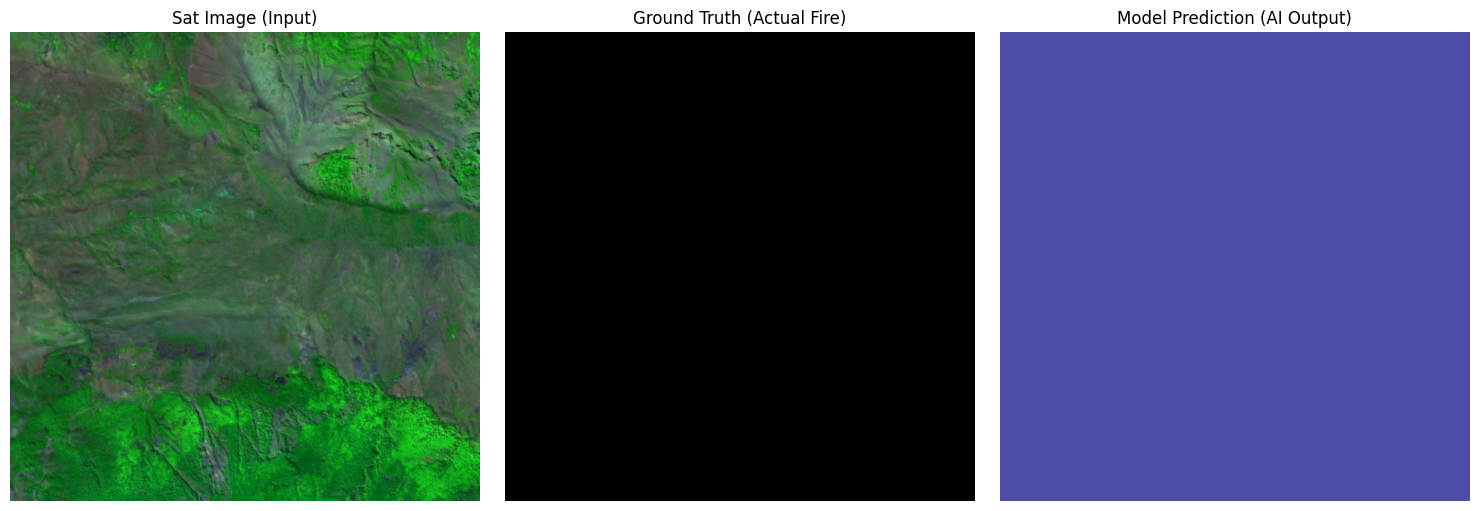

🧐 Inspecting Test Sample #46...


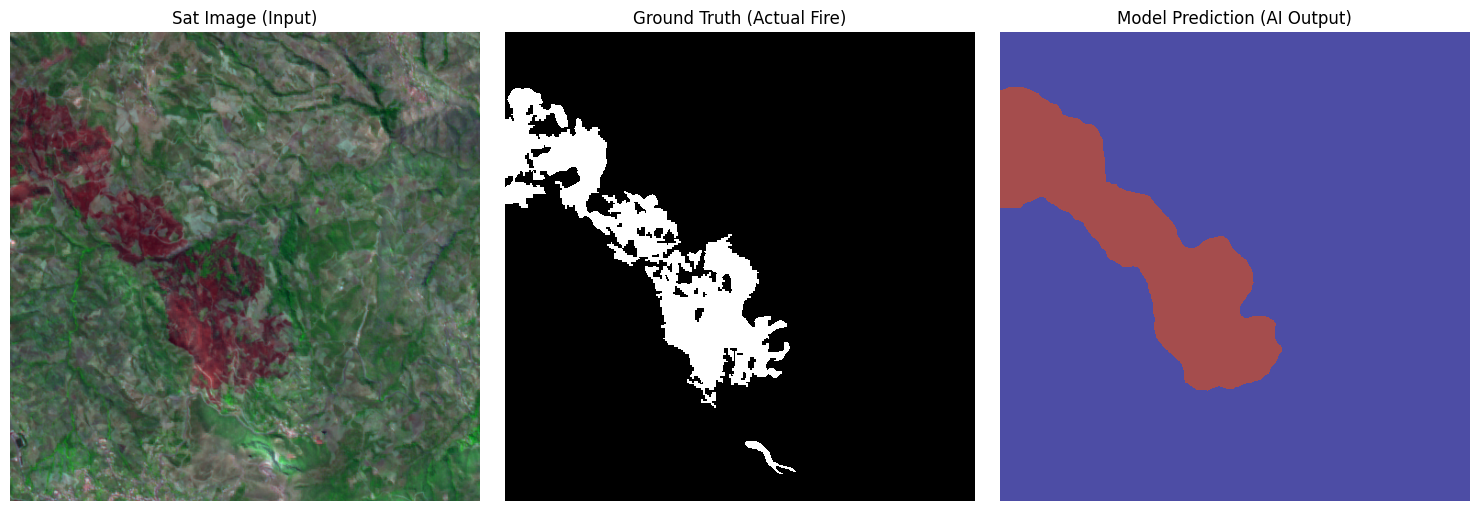

🧐 Inspecting Test Sample #12...


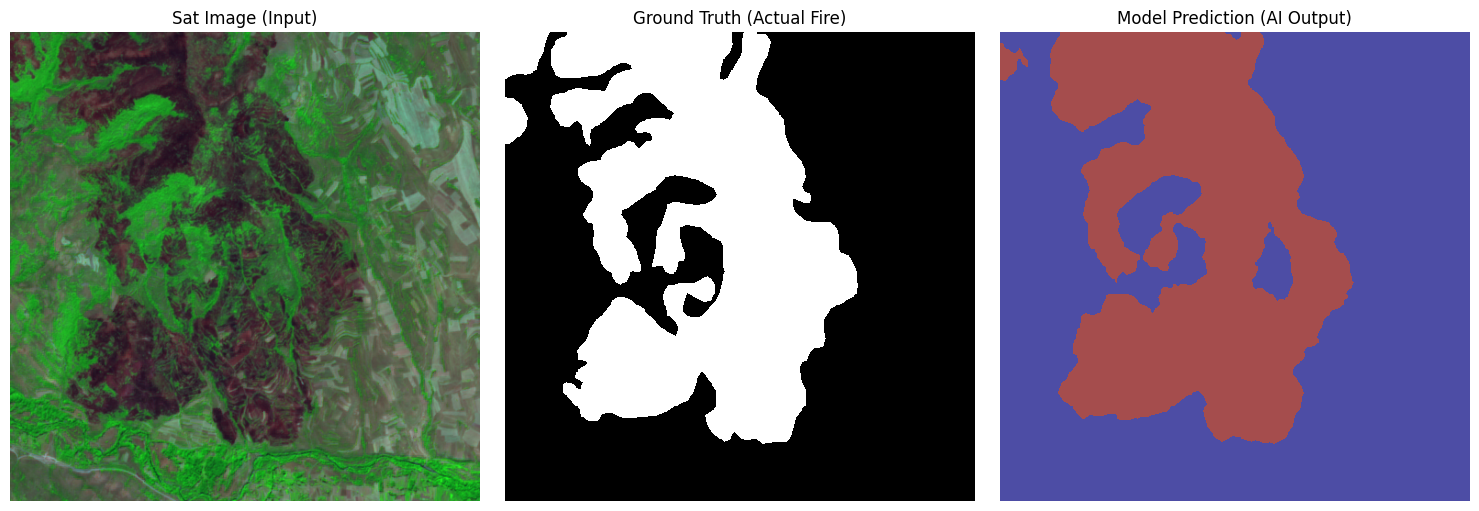

In [ ]:
# --- Visual Test & Inspection Cell ---
import matplotlib.pyplot as plt
import torch
import numpy as np
import random

# 1. Define Test Set (Using Validation set for Baseline Phase)
test_ds = val_ds

def visualize_prediction(dataset, model, index=None):
    """
    Visualizes: Input Image | Ground Truth Mask | Predicted Mask
    """
    # Pick a random image if no index provided
    if index is None:
        index = random.randint(0, len(dataset)-1)

    print(f"🧐 Inspecting Test Sample #{index}...")

    # Load Data
    sample = dataset[index]
    image = sample['pixel_values']
    label = sample['labels']

    # Run Inference
    model.eval()
    model.to(Config.DEVICE)
    with torch.no_grad():
        # Add batch dimension (C, H, W) -> (1, C, H, W)
        input_tensor = image.unsqueeze(0).to(Config.DEVICE)
        outputs = model(pixel_values=input_tensor)

        # Upsample logits to original size (SegFormer output is 1/4th size)
        logits = nn.functional.interpolate(
            outputs.logits,
            size=label.shape[-2:], # Match Ground Truth H,W
            mode="bilinear",
            align_corners=False
        )

        # Get Prediction (Argmax)
        pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()

    # Prepare for Plotting
    # Image: (C, H, W) -> (H, W, C) & Denormalize for display
    img_display = image.permute(1, 2, 0).numpy()

    # Normalize image to 0-1 range for matplotlib if it isn't already
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Original Image
    axes[0].imshow(img_display)
    axes[0].set_title("Sat Image (Input)")
    axes[0].axis("off")

    # 2. Ground Truth
    axes[1].imshow(label, cmap="gray", interpolation="nearest")
    axes[1].set_title("Ground Truth (Actual Fire)")
    axes[1].axis("off")

    # 3. Prediction
    axes[2].imshow(pred_mask, cmap="jet", alpha=0.7, interpolation="nearest")
    axes[2].set_title("Model Prediction (AI Output)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# --- Run Visualization ---
# Run this multiple times to see different "Test" examples
for i in range(3):
    visualize_prediction(test_ds, model)

In [ ]:
# --- Save Model to Google Drive ---
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
# This uses your existing Config class to find the local model
local_model_path = f"./models/{Config.EXPERIMENT_NAME}"

# Define where you want it on Drive
# It will create a folder "Satellite_Project_Models" if it doesn't exist
drive_dest_path = f"/content/drive/MyDrive/Satellite_Project_Models/{Config.EXPERIMENT_NAME}"

# 3. Copy the Model
if os.path.exists(local_model_path):
    print(f"\n🚀 Copying model from {local_model_path} to {drive_dest_path}...")

    # If a version already exists on Drive, remove it to ensure we save the latest
    if os.path.exists(drive_dest_path):
        print("   (Overwriting existing version on Drive...)")
        shutil.rmtree(drive_dest_path)

    # Copy the directory
    shutil.copytree(local_model_path, drive_dest_path)
    print("✅ Success! Model safely saved to Google Drive.")
else:
    print(f"❌ Error: Could not find local model at {local_model_path}. Did the training finish?")

Mounted at /content/drive

🚀 Copying model from ./models/segformer_b0_cems_fire to /content/drive/MyDrive/Satellite_Project_Models/segformer_b0_cems_fire...
✅ Success! Model safely saved to Google Drive.
